## 1. Setup

In [106]:
import sys
import re
import json
import ast
import math
import random
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.transforms as mtransforms
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

EVAL_DIR = Path().resolve()
ROOT     = EVAL_DIR.parent
SRC_DIR  = ROOT / 'src'

for p in [str(ROOT), str(SRC_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f'EVAL_DIR : {EVAL_DIR}')
print(f'ROOT     : {ROOT}')
print(f'SRC_DIR  : {SRC_DIR}')

EVAL_DIR : /Users/pelle/Development/GitHub/aac-mcp-agent/hf_dataset_annotation
ROOT     : /Users/pelle/Development/GitHub/aac-mcp-agent
SRC_DIR  : /Users/pelle/Development/GitHub/aac-mcp-agent/src


## 2. Dataset load

In [107]:
RAW_PATH       = EVAL_DIR / 'eval_raw.parquet'
ANNOTATED_PATH = EVAL_DIR / 'eval_annotated.parquet'

df_raw       = pd.read_parquet(RAW_PATH)
df_annotated = pd.read_parquet(ANNOTATED_PATH)

In [108]:
df_raw

,sentence,concept,best_id
0,skier ski down the mountain,"[skier, ski, the mountain]","[35959, 3097, 23977]"
1,a skier be ski down a mountain .,"[a skier, ski, a mountain]","[3097, 3098, 23977]"
2,three skiers be ski on a snowy mountain .,"[three skiers, ski, a snowy mountain]","[35959, 28815, 38261]"
3,the dog be wag his tail .,"[the dog, wag, his tail]","[7139, 36179, 5967]"
4,a dog wag his tail at the boy .,"[a dog, wag, his tail, the boy]","[11176, 25996, 5967, 36481]"
...,...,...,...
54792,type of place of worship of artwork show a tem...,"[type, place, worship, artwork, a temple, reli...","[11098, 21861, 24189, 21859, 36550, 23833]"
54793,a lot of people be gather in a pier next to a ...,"[a lot, people, gather, a pier, a lake, people...","[36081, 11486, 7116, 37115, 6159, 28031]"
54794,dimensional sculpture in the round mythical be...,"[dimensional sculpture, the round mythical bea...","[21859, 6237, 5472, 21861, 4603, 6573, 7302]"
54795,type of place of worship of artwork feature a ...,"[type, place, worship, artwork feature, a temp...","[7074, 21861, 24189, 38382, 36550, 27060]"


In [109]:
df_annotated

,sentence,concept,best_id,caregiver_clear,caregiver_vague,time_of_day,event_time,schedule,tod_selection,split
0,skier ski down the mountain,"[skier, ski, the mountain]","[35959, 3097, 23977]",The skier is going down the mountain at 05:45 ...,that snowy thing,morning,05:45,"[{'title': 'Ski run', 'start_time': '05:45', '...",model-forced,both
1,a skier be ski down a mountain .,"[a skier, ski, a mountain]","[3097, 3098, 23977]",A skier is skiing down the mountain at 05:00 t...,"ski thing, beautiful view",morning,05:00,"[{'title': 'Ski run', 'start_time': '05:00', '...",model-forced,both
2,three skiers be ski on a snowy mountain .,"[three skiers, ski, a snowy mountain]","[35959, 28815, 38261]",Three skiers are skiing on the snowy mountain ...,"skiing thing, cold weather",morning,05:15,"[{'title': 'Ski run', 'start_time': '05:15', '...",model-forced,both
3,the dog be wag his tail .,"[the dog, wag, his tail]","[7139, 36179, 5967]",The dog is wagging its tail at 21:15,tail wagging thing,night,21:15,[],sampled,both
4,a dog wag his tail at the boy .,"[a dog, wag, his tail, the boy]","[11176, 25996, 5967, 36481]",The dog is wagging its tail at the boy at 16:30,"the dog thing, playing again",afternoon,16:30,[],model-forced,both
...,...,...,...,...,...,...,...,...,...,...
54792,type of place of worship of artwork show a tem...,"[type, place, worship, artwork, a temple, reli...","[11098, 21861, 24189, 21859, 36550, 23833]",They visit the temple at 10:15 this morning fo...,"temple thing, spiritual vibes",morning,10:15,"[{'title': 'Temple visit', 'start_time': '10:1...",model-forced,both
54793,a lot of people be gather in a pier next to a ...,"[a lot, people, gather, a pier, a lake, people...","[36081, 11486, 7116, 37115, 6159, 28031]",Many people are gathering on the pier near the...,"the lake thing, busy spot",afternoon,17:45,"[{'title': 'Kayaking gathering', 'start_time':...",model-forced,both
54794,dimensional sculpture in the round mythical be...,"[dimensional sculpture, the round mythical bea...","[21859, 6237, 5472, 21861, 4603, 6573, 7302]",They are carving dimensional sculptures of myt...,"that crafty thing, in the round",afternoon,16:30,[{'title': 'Dimensional sculpture carving sess...,model-forced,both
54795,type of place of worship of artwork feature a ...,"[type, place, worship, artwork feature, a temp...","[7074, 21861, 24189, 38382, 36550, 27060]",He visits temple with artistic elements at 08:...,"that spiritual place, always beautiful",morning,08:00,"[{'title': 'Temple visit', 'start_time': '08:0...",model-forced,both


## 3. Data cleaning

### 3.1 Drop the rows with null values in annotation columns (where the annotation process was incomplete).


In [110]:
critical_cols = df_annotated.columns[3:]
before = len(df_annotated)
df_annotated = df_annotated.dropna(subset=critical_cols)
print(f'Dropped {before - len(df_annotated)} rows, the remaining are {len(df_annotated)} rows.')

Dropped 5 rows, the remaining are 54792 rows.


### 3.2. Ensure that there is no `{TIME}` left unreplaced.

In [111]:
mask_time = df_annotated[critical_cols].apply(lambda s: s.astype(str).str.contains("{TIME}", regex=False)).any(axis=1)
rows_with_time = df_annotated[mask_time]
for c in rows_with_time.columns:
    for i in rows_with_time.index:
        if "{TIME}" in str(rows_with_time.loc[i, c]):
            print(rows_with_time.loc[i, c])

[{'title': 'Retaining wall installation', 'start_time': '13:00', 'location': 'construction site', 'description': 'tallest point to be {TIME} feet'}]
[{'title': 'Pro team game', 'start_time': '19:45', 'location': 'City Arena', 'description': 'Leaving for the game at {TIME}'}]
[{'title': 'Wildflower searching', 'start_time': '09:30', 'location': 'the state', 'description': 'Enjoy the beauty of wildflowers during {TIME}'}]
[{'title': 'Museum visit', 'start_time': '07:45', 'location': 'museum', 'description': 'Last design by the architect who died before {TIME}'}]
[{'title': 'Emergency assistance at collision site', 'start_time': '15:00', 'location': 'Eastbound {TIME}', 'description': 'Assisting passengers and vehicles involved in collision'}]


The `{TIME}` placeholder is only in schedule and only in non essential fields, so we can simply set then to "".


In [112]:
def clean_dict_placeholders(item_list):
    new_list = []
    for d in item_list:
        new_dict = {}
        for k, v in d.items():
            if isinstance(v, str) and "{TIME}" in v:
                print(k, v)
                new_dict[k] = ""
            else:
                new_dict[k] = v
        new_list.append(new_dict)
    return new_list

df_annotated['schedule'] = df_annotated['schedule'].apply(clean_dict_placeholders)

description tallest point to be {TIME} feet
description Leaving for the game at {TIME}
description Enjoy the beauty of wildflowers during {TIME}
description Last design by the architect who died before {TIME}
location Eastbound {TIME}


### 3.3 Ensure that all the splits are complete (both inputs are generated)

In [113]:
df_annotated["split"].value_counts()

split
both    54792
Name: count, dtype: int64

The annotation is present in both the inputs in all rows, we can remove this distinction though.

In [114]:
df_annotated.drop(columns=["split"], inplace=True)

### 3.4 Ensure that the generated `time_of_day` is coherent with other generated fields.

In [115]:
TODS   = ["morning", "afternoon", "evening", "night"]
FIELDS = ["caregiver_clear", "caregiver_vague", "schedule"]

# Extract conflicts using a nested list comprehension
conflicts = [
    {"index": i, "expected": str(row["time_of_day"]).lower(), "conflict": t, "field": f, "content": row[f]}
    for i, row in df_annotated.iterrows()
    for f in FIELDS
    for t in TODS if t in str(row[f]).lower() and t != str(row["time_of_day"]).lower()
]

df_conflicts = pd.DataFrame(conflicts)
print(f"Conflicts found: {len(df_conflicts)}" if not df_conflicts.empty else "No conflicts.")
display(df_conflicts)

Conflicts found: 745


,index,expected,conflict,field,content
0,13,night,evening,caregiver_clear,He is watching a match with his fan at 23:15 t...
1,162,evening,night,caregiver_clear,Friends and family gather around the fireplace...
2,294,night,evening,caregiver_clear,The zombie hand is grabbing a gift box at 23:4...
3,333,night,morning,caregiver_clear,The cat is sleeping in a tree at 22:15 this mo...
4,414,evening,morning,caregiver_clear,The employee is working at the restaurant from...
...,...,...,...,...,...
740,54276,night,evening,caregiver_clear,She's seeing the new nebula view with the hidd...
741,54360,night,evening,caregiver_clear,She is taking illegal substances at 21:15 this...
742,54381,night,evening,caregiver_clear,The gambler leaves to chat with Robert DeNiro ...
743,54424,night,evening,caregiver_clear,The athlete is taking part in the celebrities ...


In [116]:
df_conflicts["field"].value_counts()

field
caregiver_clear    571
schedule           100
caregiver_vague     74
Name: count, dtype: int64

In [117]:
def global_tod_fixer(row):
    expected   = str(row["time_of_day"]).lower()
    wrong_tods = [t for t in TODS if t != expected]

    def replace_all(text):
        if not isinstance(text, str):
            return text
        for wrong in wrong_tods:
            # Replaces 'night' with 'morning' and 'Night' with 'Morning'
            text = text.replace(wrong, expected).replace(wrong.capitalize(), expected.capitalize())
        return text

    # First the caregiver_* fields, they are just text
    for col in ["caregiver_clear", "caregiver_vague"]:
        if col in row and pd.notna(row[col]):
            row[col] = replace_all(row[col])

    # The schedule field, which has a more complex structure
    if "schedule" in row and isinstance(row["schedule"], list):
        for entry in row["schedule"]:
            for key, value in entry.items():
                if isinstance(value, str):
                    entry[key] = replace_all(value)

    return row

# Apply to the whole dataset
df_annotated = df_annotated.apply(global_tod_fixer, axis=1)

### 3.5 Original dataset problems

In [118]:
null_ids = []
for i, row in df_raw.iterrows():
    ids = row["best_id"]
    for id in ids:
        if id is None : 
            null_ids.append(i)
print(f"Rows with None ids: {len(null_ids)}")
df_raw.drop(index=null_ids, inplace=True)

unique_ids = []
for i, row in df_raw.iterrows():
    ids = row["best_id"]
    for id in ids:
        if id is None : 
            null_ids.append(i)
        if id not in unique_ids: 
            unique_ids.append(id)

print(f"N. of unique ids: {len(unique_ids)}")

Rows with None ids: 7
N. of unique ids: 6748


In [119]:
import os
print(f"N. of pictograms: {len(os.listdir('../datasets/pictograms'))}")

N. of pictograms: 13780


In [120]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
import requests

base_url = "https://api.arasaac.org/v1/pictograms/en"
timeout = 10
max_workers = 64

session = requests.Session()

def check_id(pictogram_id):
    try:
        r = session.get(
            f"{base_url}/{pictogram_id}",
            timeout=timeout
        )

        if r.status_code != 200:
            return pictogram_id

    except Exception:
        return pictogram_id

    return None


error_ids = []

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {
        executor.submit(check_id, pictogram_id): pictogram_id
        for pictogram_id in unique_ids
    }

    for future in tqdm(
        as_completed(futures),
        total=len(futures)
    ):
        result = future.result()

        if result is not None:
            error_ids.append(result)

print(f"Errors: {len(error_ids)}")

100%|██████████| 6748/6748 [00:31<00:00, 212.80it/s]

['23977', '12216', '23774', '24878', '29010', '24910', '11444', '26273', '27174', '9212', '24155', '16369', '12209', '27788', '28172', '26272', '12184', '23430', '19522', '25424', '16859', '27926', '12081', '11419', '11113', '25462', '25254', '11667', '11438', '11408', '26504', '21579', '16329', '28160', '26042', '12151', '23872', '21797', '25888', '28146', '12057', '23691', '27938', '17239', '12061', '17267', '11671', '26800', '12066', '27789', '21490', '21427', '26413', '25197', '26841', '26291', '12135', '26713', '25092', '12219', '23433', '23600', '27825', '23428', '25468', '26741', '21971', '23486', '27769', '25508', '23734', '24227', '16203', '12248', '5595', '24297', '21411', '12149', '20125', '24578', '12063', '25561', '28948', '23672', '28633', '25480', '12090', '26633', '16653', '9209', '11504', '11149', '23498', '25176', '26926', '9215', '23692', '23964', '23447', '24492', '26490', '27084', '23484', '26918', '26994', '12175', '25130', '11435', '27894', '12087', '11138', '120

In [121]:
meaningless_rows = []
for i, row in df_raw.iterrows():
    ids = row["best_id"]
    for id in ids:
        if id in error_ids: 
            meaningless_rows.append(i)
            continue
print(f"Rows with made up ids: {len(meaningless_rows)}")

Rows with made up ids: 24974


In [123]:
existing_ids = set(unique_ids) - set(error_ids)
print(f"Existing ids: {len(existing_ids)}")

Existing ids: 5812


## 4. Data analysis

### 4.1 Length distribution of both the generated inputs

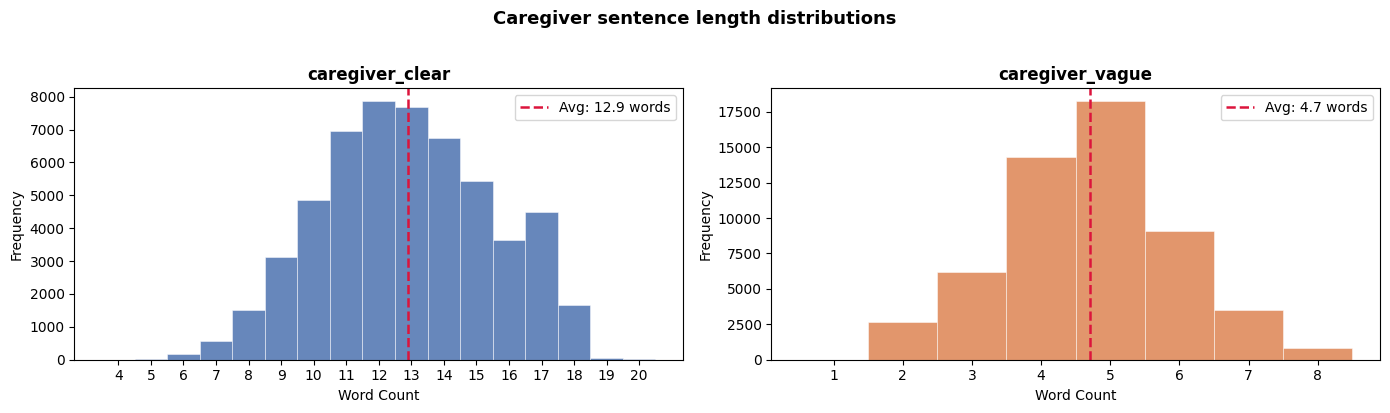

In [13]:
COLORS = {'clear': '#4C72B0', 'vague': '#DD8452'}
_df = df_annotated.copy()

_df['len_clear'] = _df['caregiver_clear'].str.split().str.len()
_df['len_vague']  = _df['caregiver_vague'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
configs = [
    (axes[0], 'len_clear', 'caregiver_clear', COLORS['clear']),
    (axes[1], 'len_vague', 'caregiver_vague', COLORS['vague'])
]

for ax, col, label, color in configs:
    vals = _df[col].dropna()
    start, end = int(vals.min()), int(vals.max())
    bins = [t - 0.5 for t in range(start, end + 2)]  # to center bin xtick
    ax.hist(vals, bins=bins, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    avg = vals.mean()
    ax.axvline(avg, color='crimson', lw=1.8, ls='--', label=f'Avg: {avg:.1f} words')
    ax.set_xticks(range(start, end + 1, 1))
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Caregiver sentence length distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

This is quite good, the distribution is quite normal and balanced. On average, the clear input length is more than twice the vague input length, which is reasonable since the first one has to be more informative.

### 4.2 The distribution of the generated `time_of_day`.

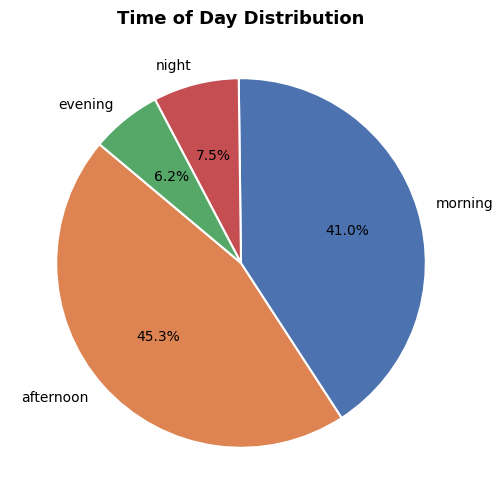

In [14]:
TOD_COLORS = {'morning': '#4C72B0', 'afternoon': '#DD8452', 'evening': '#55A868', 'night': '#C44E52'}
tod_counts = _df['time_of_day'].value_counts()
colors_pie  = [TOD_COLORS[k] for k in tod_counts.index]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    tod_counts.values,
    labels=tod_counts.index,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
for t in autotexts:
    t.set_fontsize(10)
ax.set_title('Time of Day Distribution', fontsize=13, fontweight='bold')
plt.show()

/var/folders/n9/r8x6svc56fjb_2b7zb4tztr80000gn/T/ipykernel_20005/837360698.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed  = pd.to_datetime(_df['event_time'], errors='coerce')


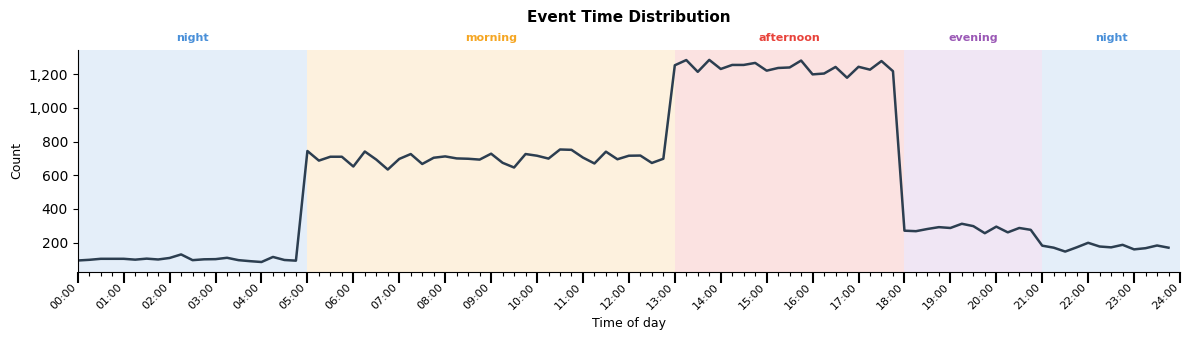

In [15]:
_SLOT_RANGES = [
    ("night",     0,   5,  "#4A90D9"),
    ("morning",   5,  13,  "#F5A623"),
    ("afternoon", 13, 18,  "#E8423A"),
    ("evening",   18, 21,  "#9B59B6"),
    ("night",     21, 24,  "#4A90D9"),
]

parsed  = pd.to_datetime(_df['event_time'], errors='coerce')
minutes = parsed.dt.hour * 60 + parsed.dt.minute
counts  = minutes.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(counts.index.values, counts.values, linewidth=1.8, color='#2c3e50')
ax.set_xlim(0, 1440)

# the MM where generated each 15 mins
tick_pos    = np.arange(0, 1441, 15)
tick_labels = [f"{m//60:02d}:00" if m % 60 == 0 else "" for m in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
for tick in ax.xaxis.get_major_ticks():
    is_hour = tick.get_loc() % 60 == 0
    tick.tick1line.set_markersize(8 if is_hour else 3)
    tick.tick1line.set_markeredgewidth(1.5 if is_hour else 0.8)

# times of day colored
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
for name, start, end, color in _SLOT_RANGES:
    ax.axvspan(start * 60, end * 60, alpha=0.15, color=color, linewidth=0)
    ax.text((start + end) / 2 * 60, 1.03, name,
            transform=trans, ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=color, clip_on=False)

ax.set_title('Event Time Distribution', fontsize=11, fontweight='bold', pad=20)
ax.set_xlabel('Time of day', fontsize=9)
ax.set_ylabel('Count', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

The most important thing as we wanted is that the distribution is homogeneous inside each time_of_day bin.This is maybe not that much realistic (the borders are too sharp) but we don't have information to correctly unbalance it. In previous experiments the model was constantly choosing few datetimes and overrepresent them so maybe this situation is more useful.

### 4.4 Vocabulary distribution of the two kind of inputs in different times and normalized per `time_of_day`.

Simple frequencies were tried but weren't meaningful enough, so the current approach uses TF-IDF scores, in order to better characterize bin frequencies since we evaluate at the same time the frequency of a word in a certain moment and its rarity in others.

Top-50 words are picked by inter-bin variance, so globally uniform words (high everywhere) are suppressed. Bins with < 20 tokens are masked to avoid night-time spikes.

/var/folders/n9/r8x6svc56fjb_2b7zb4tztr80000gn/T/ipykernel_20005/4192287063.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _parsed = pd.to_datetime(_df['event_time'], errors='coerce')


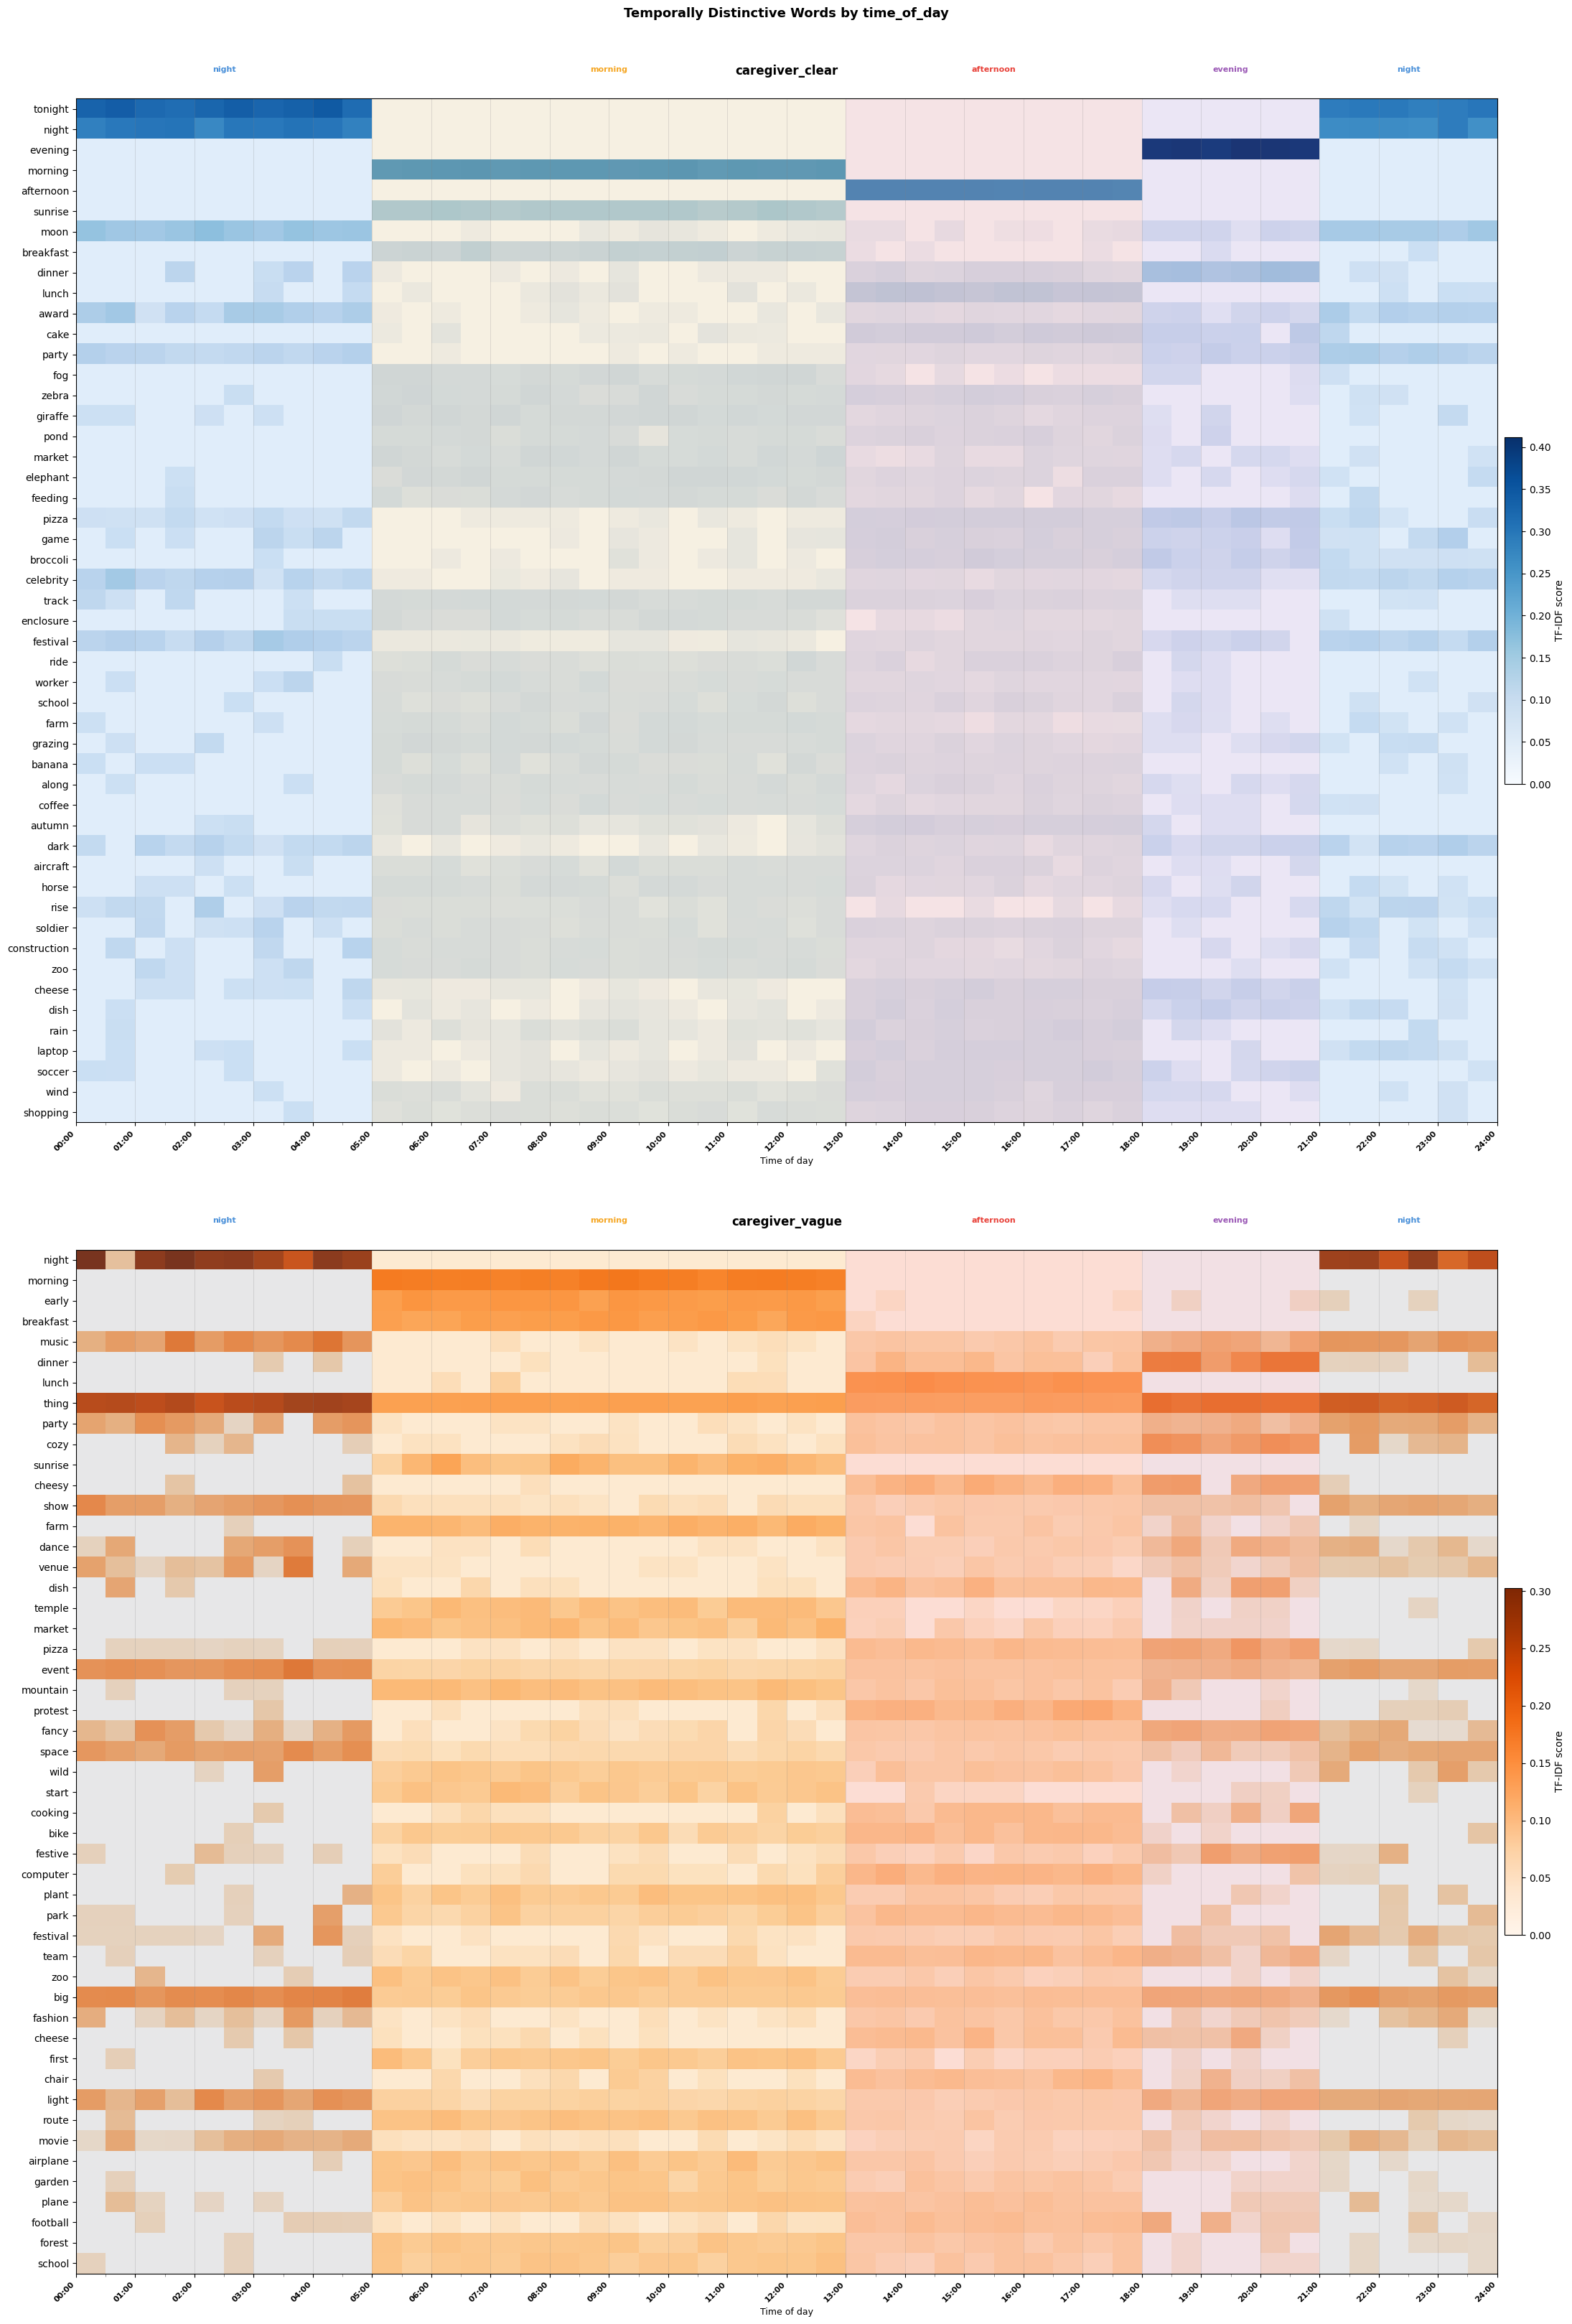

In [16]:
_STOPWORDS  = set(stopwords.words('english'))
_lemmatizer = WordNetLemmatizer()
_TOKEN_RE   = re.compile(r'[a-z]+')

def _lemmatize_series(series: pd.Series) -> list[str]:
    """Una stringa di lemmi per ogni bin (già aggregato)."""
    out = []
    for text in series.fillna(''):
        tokens = _TOKEN_RE.findall(text.lower())
        lemmas = [
            _lemmatizer.lemmatize(t) for t in tokens
            if t not in _STOPWORDS and len(t) >= 3
        ]
        out.append(' '.join(lemmas))
    return out

BIN_MIN = 30
N_TOP = 50
MIN_BIN_TOKS = 20

_parsed = pd.to_datetime(_df['event_time'], errors='coerce')
_df['_min'] = _parsed.dt.hour * 60 + _parsed.dt.minute
_df['_bin'] = (_df['_min'] // BIN_MIN) * BIN_MIN
time_bins = list(range(0, 1440, BIN_MIN))

def _tfidf_matrix(col: str):
    bin_texts, bin_counts = {}, {}
    for b in time_bins:
        sub = _df.loc[_df['_bin'] == b, col]
        joined = ' '.join(sub.fillna('').tolist())
        lemmatized = _lemmatize_series(pd.Series([joined]))[0]
        bin_texts[b] = lemmatized
        bin_counts[b] = len(lemmatized.split())

    valid_bins = [b for b in time_bins if bin_counts[b] >= MIN_BIN_TOKS]
    docs = [bin_texts[b] for b in valid_bins]

    vec   = TfidfVectorizer(max_features=300, sublinear_tf=True)
    tfidf = vec.fit_transform(docs).toarray()
    vocab = np.array(vec.get_feature_names_out())

    # top N_TOP words by inter-bin variance
    top_idx   = np.argsort(tfidf.var(axis=0))[::-1][:N_TOP]
    top_words = vocab[top_idx].tolist()
    mat       = tfidf[:, top_idx]

    full_mat = np.full((len(time_bins), N_TOP), np.nan)
    for i, b in enumerate(valid_bins):
        full_mat[time_bins.index(b)] = mat[i]

    return full_mat, top_words

mat_clear, words_clear = _tfidf_matrix('caregiver_clear')
mat_vague, words_vague = _tfidf_matrix('caregiver_vague')

def _add_tod_bands(ax):
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    for name, h_start, h_end, color in _SLOT_RANGES:
        ax.axvspan(h_start * 60, h_end * 60, alpha=0.13, color=color, linewidth=0, zorder=0)
        ax.text(
            (h_start + h_end) / 2 * 60, 1.025, name,
            transform=trans, ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=color, clip_on=False,
        )

configs = [
    (mat_clear, words_clear, 'Blues',   'caregiver_clear'),
    (mat_vague, words_vague, 'Oranges', 'caregiver_vague'),
]

fig, axes = plt.subplots(2, 1, figsize=(22, 32))

for ax, (mat, words, cmap, title) in zip(axes, configs):
    n  = len(words)
    im = ax.imshow(
        mat.T,
        aspect='auto',
        cmap=cmap,
        interpolation='nearest',
        extent=[0, 1440, n - 0.5, -0.5],
    )
    ax.set_xlim(0, 1440)
    ax.set_xticks(range(0, 1441, 60))
    ax.set_xticklabels(
        [f"{h:02d}:00" for h in range(25)],
        rotation=45, ha='right', fontsize=8, fontweight='bold',
    )
    ax.set_xticks(range(0, 1441, BIN_MIN), minor=True)
    ax.tick_params(axis='x', which='minor', length=3, width=0.6, color='grey')
    ax.set_yticks(range(n))
    ax.set_yticklabels(words, fontsize=10)
    for h in range(25):
        ax.axvline(h * 60, color='grey', linewidth=0.4, alpha=0.4, zorder=1)
    _add_tod_bands(ax)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=24)
    ax.set_xlabel('Time of day', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.012, pad=0.005, label='TF-IDF score')

plt.suptitle(
    'Temporally Distinctive Words by time_of_day',
    fontsize=13, fontweight='bold', y=1.01,
)
plt.tight_layout(h_pad=5)
plt.show()

_df.drop(columns=['_min', '_bin'], inplace=True)

- `caregiver_clear`: 
    - the times of day are mutually exclusive, as we ensured in data cleaning.
    - even if not perfectly, also other clearly time-bounded activity do follow their bin, like breakfast, dinner, lunch etc.
    - the afternoon then becomes quite homogeneous as we would expect by its presence in the dataset.
    - the morning also show a cluster of "zoo" events, consistent with typical zoo-visit timing.

- `caregiver_vague`: 
    - the times of day are mutually exclusive, as we ensured in data cleaning.
    - the "thing" constant presence shows that it is structurally central to vague descriptions, not incidental. This is a hint to prove the incompleteness/vagueness of the vocabulary used.
    - the words seems to be less bin-dependant, despite the first words, suggesting a less clear temportal structure. This is interesting since vagueness is effectively time-independant.

### 4.5 How much `schedule` is well formed?

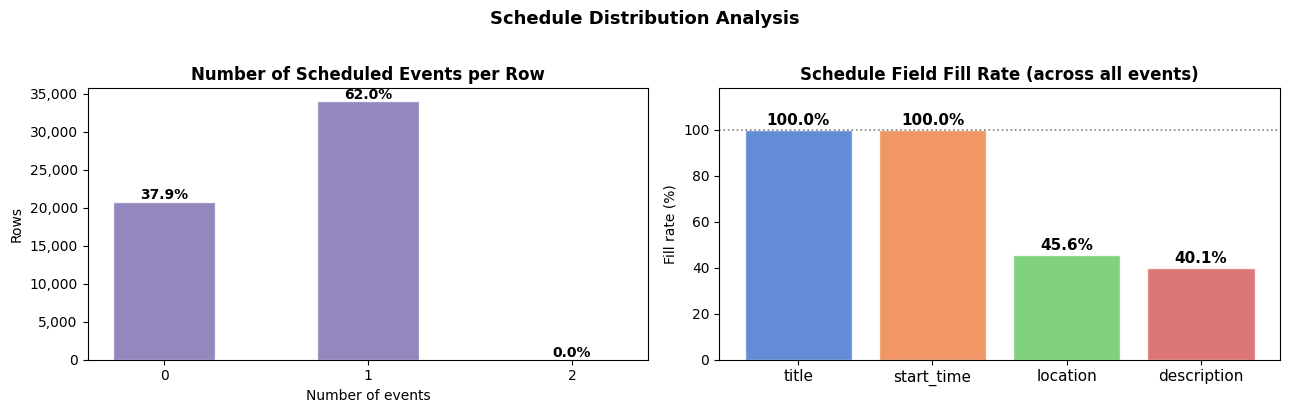

In [17]:
_df['n_events'] = _df['schedule'].apply(lambda s: len(s) if s is not None else 0)
nev_counts = _df['n_events'].value_counts().sort_index()
all_events = [ev for sched in _df['schedule'] if sched is not None for ev in sched]
fields     = ['title', 'start_time', 'location', 'description']
fill_rates = {f: sum(1 for ev in all_events if ev.get(f) is not None) / len(all_events) * 100
              for f in fields}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# n_events distribution
bars0 = axes[0].bar(nev_counts.index.astype(str), nev_counts.values,
                    color='#8172B2', alpha=0.85, edgecolor='white', width=0.5)
for bar, (k, v) in zip(bars0, nev_counts.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{v/len(_df)*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Number of Scheduled Events per Row', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of events')
axes[0].set_ylabel('Rows')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# fill-rate fields
field_colors = ['#4878D0', '#EE854A', '#6ACC65', '#D65F5F']
bars1 = axes[1].bar(fill_rates.keys(), fill_rates.values(),
                    color=field_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars1, fill_rates.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Schedule Field Fill Rate (across all events)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Fill rate (%)')
axes[1].set_ylim(0, 118)
axes[1].axhline(100, color='grey', linestyle=':', linewidth=1.2)
axes[1].tick_params(axis='x', labelsize=11)

plt.suptitle('Schedule Distribution Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The two graphs show interesting insights:
1. The majority of annotations show one scheduled event, resulting in the capacity of gaining information but not the ability to fetch the correct information thanks to the time information since it has only one choice, for this reason maybe it is better to add manually a scheduled event to all of them with an uncorrelated event. This is done in the following cell.

2. All the scheduled events are formed with the essential information: title (informative to add context) and time (to fetch it if in the correct time). The other two fields are well populated even if not essential, they can help to enrich the context.

In [18]:
RNG_SEED = 42
rng = random.Random(RNG_SEED)

COLOR_REAL       = "#2a7ab5"
COLOR_DISTRACTOR = "#b8b8b8"
COLOR_EMPTY      = "#d94f3d"

DISTRACTOR_POOL = [
    # Therapies
    {"title": "Speech therapy session",      "location": "therapy centre",   "description": None},
    {"title": "Occupational therapy",        "location": "therapy centre",   "description": "fine motor skills"},
    {"title": "Physiotherapy",               "location": "rehab centre",     "description": None},
    {"title": "Music therapy",               "location": "therapy room",     "description": None},
    {"title": "Art therapy",                 "location": "therapy room",     "description": None},
    {"title": "Hydrotherapy",                "location": "pool",             "description": None},
    {"title": "Equine therapy",              "location": "riding centre",    "description": None},
    {"title": "Sensory integration session", "location": "therapy centre",   "description": None},
    {"title": "Cognitive rehabilitation",    "location": "therapy centre",   "description": None},
    {"title": "AAC device training",         "location": "therapy centre",   "description": "with speech therapist"},
    # Medical appointments
    {"title": "Pediatrician visit",          "location": "clinic",           "description": "routine check-up"},
    {"title": "Neurologist appointment",     "location": "hospital",         "description": None},
    {"title": "Audiologist check",           "location": "hospital",         "description": "hearing test"},
    {"title": "Ophthalmologist visit",       "location": "eye clinic",       "description": None},
    {"title": "Dietitian appointment",       "location": "clinic",           "description": None},
    # School
    {"title": "School bus pickup",           "location": "home",             "description": None},
    {"title": "Classroom reading session",   "location": "school",           "description": None},
    {"title": "Lunch at school",             "location": "school canteen",   "description": None},
    {"title": "Support teacher session",     "location": "school",           "description": "individual support"},
    {"title": "After-school care",           "location": "school",           "description": None},
    # Routine care
    {"title": "Medication administration",   "location": "home",             "description": "morning meds"},
    {"title": "Personal care routine",       "location": "home",             "description": "bath and dressing"},
    {"title": "Caregiver home visit",        "location": "home",             "description": None},
    {"title": "Meal prep with caregiver",    "location": "home",             "description": None},
    # Social / recreational
    {"title": "Adaptive swimming lesson",    "location": "sports centre",    "description": None},
    {"title": "Park walk with caregiver",    "location": "local park",       "description": None},
    {"title": "Playdate",                    "location": "community centre", "description": None},
    {"title": "Family lunch",                "location": "home",             "description": None},
    {"title": "Inclusive sports activity",   "location": "sports centre",    "description": None},
    {"title": "Library storytime",           "location": "public library",   "description": None},
]

# Offset pool: ±[4h00–5h00] in 15-min steps — guarantees the distractor falls
# outside any reasonable narrow time-window filter around event_time
_OFFSETS_MIN = [h * 60 + m for h in range(4, 6) for m in (0, 15, 30, 45)]


def _distractor_time(event_time_str: str) -> str:
    """Returns a start_time offset by ±[4h, 5h] from event_time, with 24h wrap."""
    base  = datetime.strptime(event_time_str, "%H:%M")
    sign  = rng.choice([-1, 1])
    delta = sign * int(rng.choice(_OFFSETS_MIN))
    h, m  = divmod((base.hour * 60 + base.minute + delta) % (24 * 60), 60)
    return f"{h:02d}:{m:02d}"


def _add_distractor(row):
    template   = rng.choice(DISTRACTOR_POOL)
    distractor = {
        "title":       template["title"],
        "start_time":  _distractor_time(row["event_time"]),
        "location":    template["location"],
        "description": template["description"],
    }
    return list(row["schedule"]) + [distractor]


df_annotated["schedule"] = df_annotated.apply(_add_distractor, axis=1)

# Refresh _df so subsequent analysis cells see the updated schedule
_df = df_annotated.copy()

### 4.6 Are there any duplicates in the input? 

In [19]:
num_duplicates_clear = _df['caregiver_clear'].duplicated().sum()
num_duplicates_vague = _df['caregiver_vague'].duplicated().sum()
print(f"Duplicates: {num_duplicates_clear} in caregiver_clear, {num_duplicates_vague} in caregiver_vague")

Duplicates: 22 in caregiver_clear, 6626 in caregiver_vague


In [20]:
_df[_df['caregiver_clear'].duplicated()]['caregiver_clear'].value_counts()[:20]

caregiver_clear
There's dinner on the table at 13:30                                        3
The train arrives at the station at 05:30 this morning                      1
The sheep are grazing in the field at 07:30 this morning                    1
The plane is landing at the airport at 09:45 this morning                   1
He is having pizza for lunch at 14:30                                       1
The train is arriving at the station at 07:30 this morning                  1
The student is working on the computer at 17:00                             1
The bartender is making cocktails at the bar at 19:45 this evening          1
He is having pizza for lunch at 14:15                                       1
The couple is sleeping at home at 00:30                                     1
The train is departing from the station at 09:45 this morning               1
The horse is grazing at 05:30 this morning                                  1
The athlete looks dejected during the match at 1

There are no duplicates in practice for clear inputs.

In [21]:
_df[_df['caregiver_vague'].duplicated()]['caregiver_vague'].value_counts()[:20]

caregiver_vague
bathroom stuff                  252
that construction thing          33
wedding stuff                    32
the animal thing, same place     30
that art thing                   30
the animal thing, same spot      28
that home improvement thing      27
airport stuff                    25
that picture thing               25
the bathroom thing               24
airplane thing, same airport     22
train thing, same route          21
that big boat thing              21
the water thing, same spot       19
that animal thing, same spot     19
kitchen stuff                    19
that cheesy thing                18
that animal thing                18
weather stuff                    18
that statue thing                18
Name: count, dtype: int64

As we would expect, the duplicates are far more since the tools have to differentiate their context. Anyway a check on the tools information to see if they would really be capable of differentiating such general sentences.

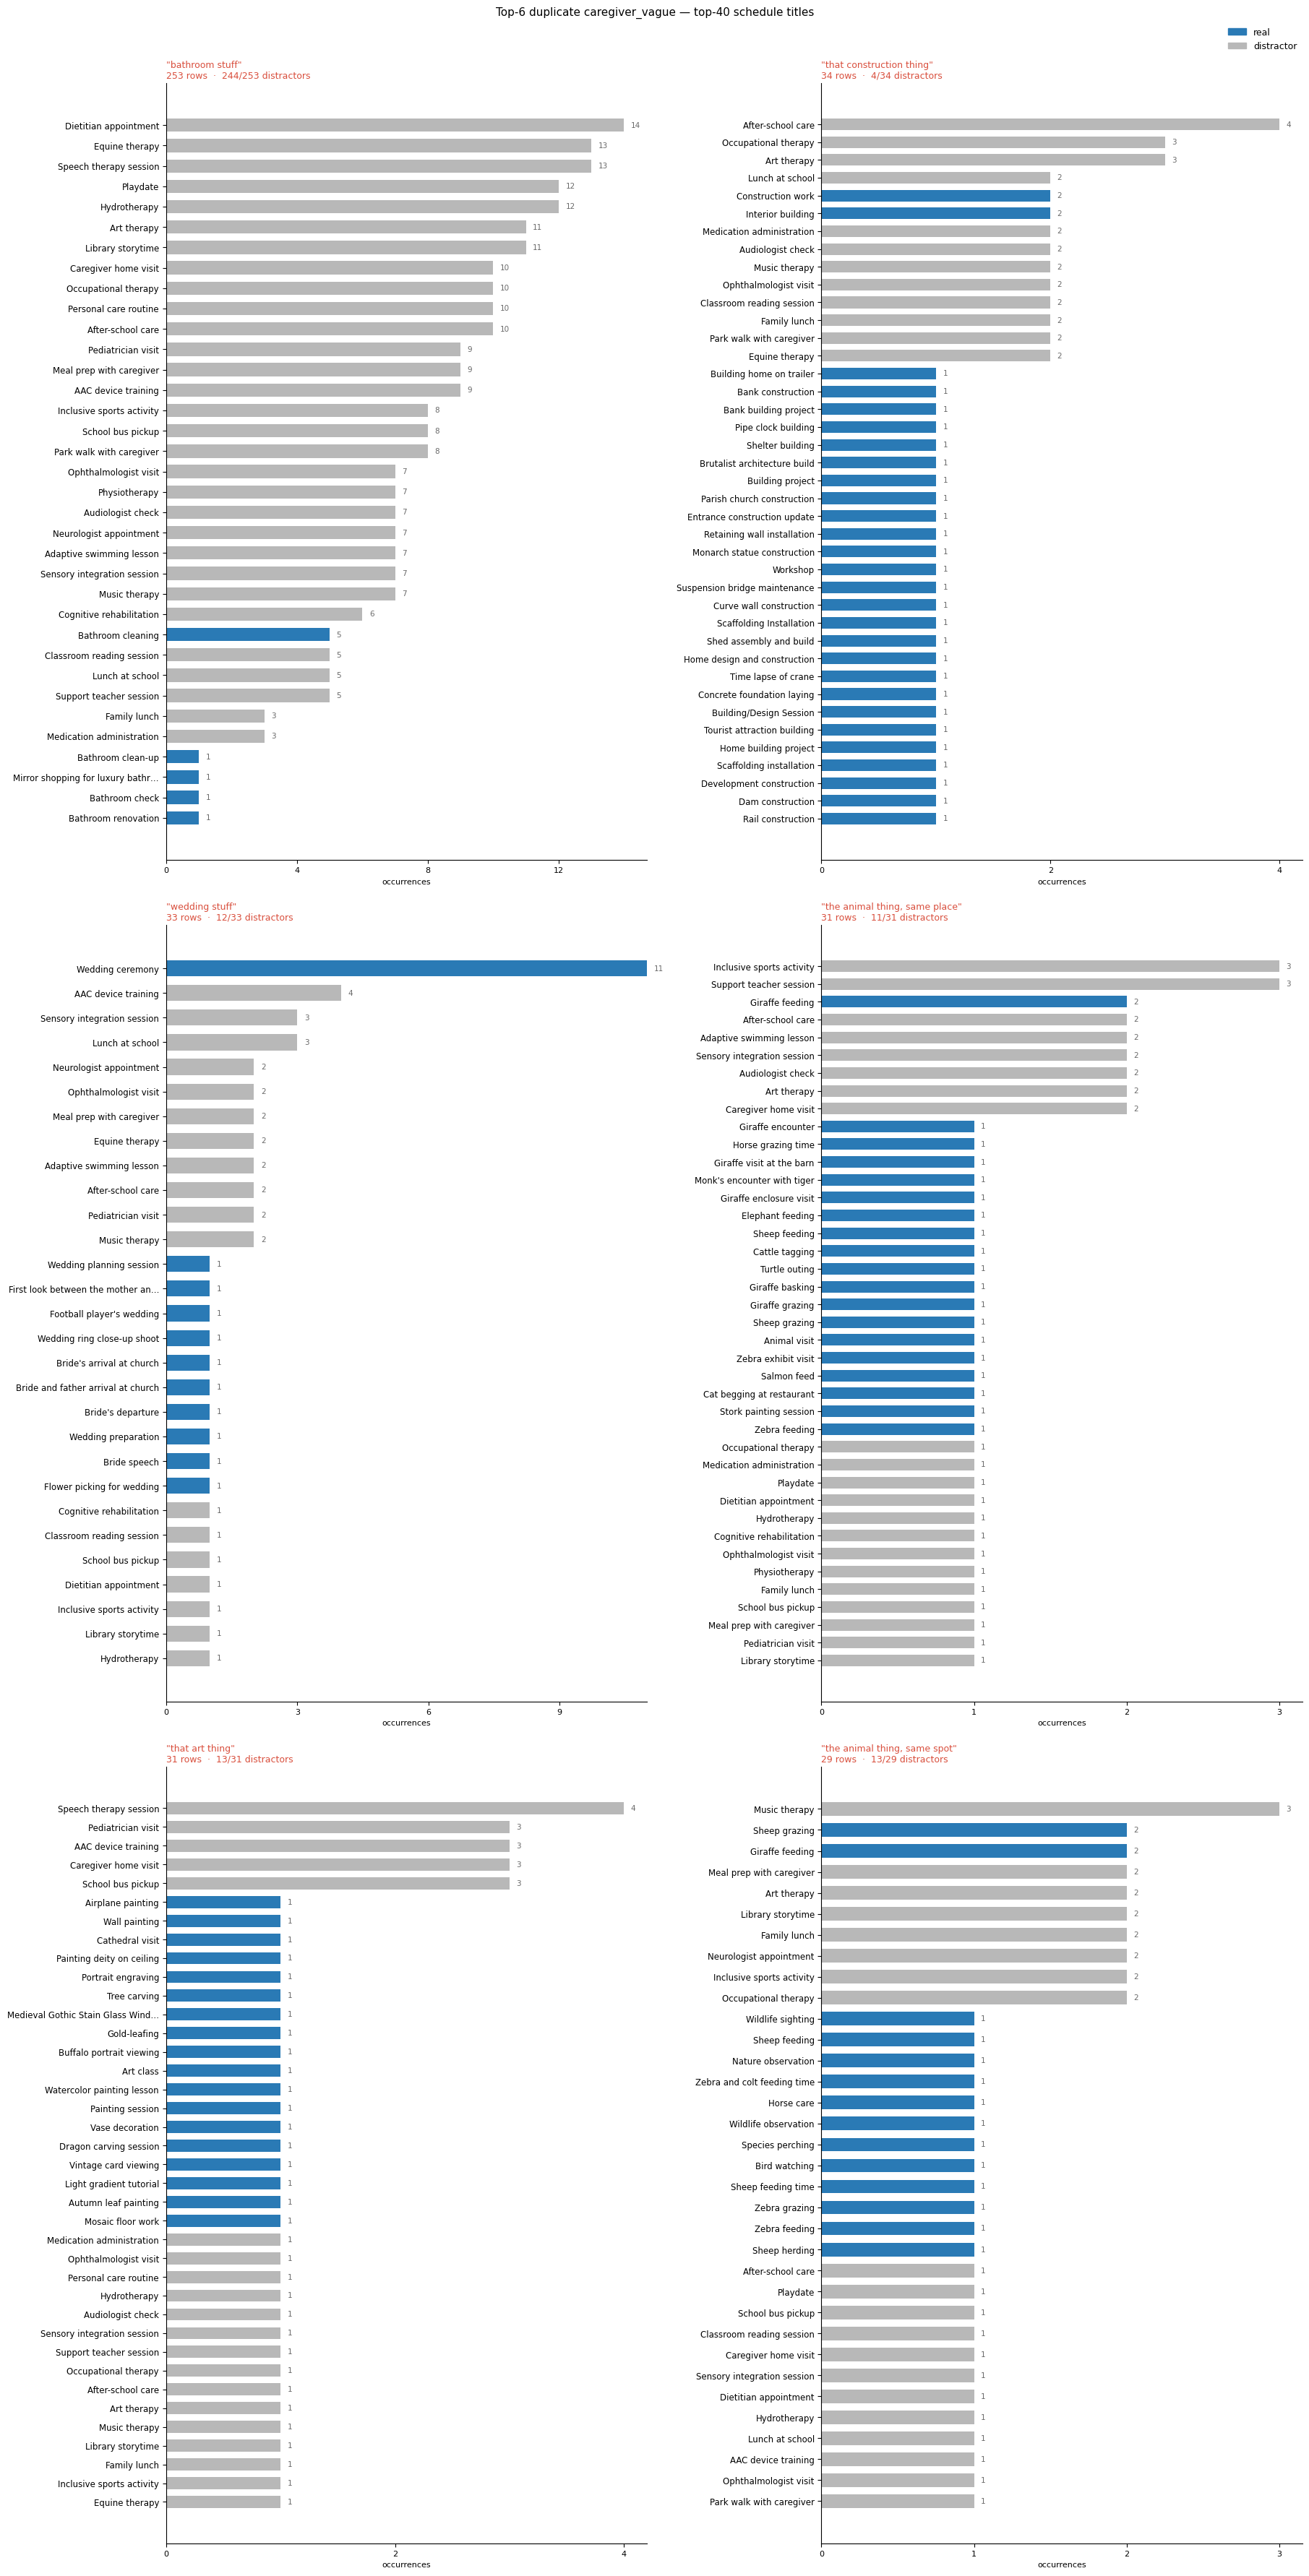

In [22]:
# A schedule event is "real"       if start_time == row event_time
# A schedule event is "distractor" if start_time != row event_time

TOP_N_VAGUE  = 6
TOP_K_TITLES = 40


def _split_titles(schedule_list, event_time: str):
    real, distractor = [], []
    if not isinstance(schedule_list, list):
        return real, distractor
    for ev in schedule_list:
        if not (isinstance(ev, dict) and "title" in ev and "start_time" in ev):
            continue
        (real if ev["start_time"] == event_time else distractor).append(ev["title"])
    return real, distractor


vague_counts = _df["caregiver_vague"].value_counts()
top_dupes    = vague_counts[vague_counts > 1].head(TOP_N_VAGUE)

panels = []
for vague_text, total_rows in top_dupes.items():
    group = _df[_df["caregiver_vague"] == vague_text]
    real_all, dist_all, no_real = [], [], 0
    for _, row in group.iterrows():
        r, d = _split_titles(row["schedule"], row["event_time"])
        if not r:
            no_real += 1
        real_all.extend(r)
        dist_all.extend(d)

    real_counts = pd.Series(real_all).value_counts()
    dist_counts = pd.Series(dist_all).value_counts()

    combined = (
        pd.concat([real_counts.rename("real"), dist_counts.rename("dist")], axis=1)
        .fillna(0).astype(int)
        .assign(total=lambda d: d["real"] + d["dist"])
        .sort_values("total", ascending=False)
        .head(TOP_K_TITLES)
    )
    panels.append((vague_text, total_rows, no_real, combined))

N_COLS = 2
N_ROWS = math.ceil(TOP_N_VAGUE / N_COLS)
ROW_H  = max(2.5, TOP_K_TITLES * 0.28)  # panel height scales with TOP_K

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(18, N_ROWS * ROW_H + 1.2), constrained_layout=True)
axes = axes.flatten()

# hide surplus axes if TOP_N_VAGUE is odd
for ax in axes[len(panels):]:
    ax.set_visible(False)

for ax, (vague_text, total_rows, no_real, combined) in zip(axes, panels):
    y      = range(len(combined))
    labels = [t if len(t) <= 34 else t[:32] + "\u2026" for t in combined.index]

    ax.barh(y, combined["real"], color=COLOR_REAL, height=0.65, label="real")
    ax.barh(y, combined["dist"], left=combined["real"], color=COLOR_DISTRACTOR, height=0.65, label="distractor")

    ax.set_yticks(list(y))
    ax.set_yticklabels(labels, fontsize=8.5)
    ax.invert_yaxis()
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=4))
    ax.tick_params(axis="x", labelsize=8)
    ax.set_xlabel("occurrences", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    # inline totals
    max_total = combined["total"].max()
    for i, tot in enumerate(combined["total"]):
        ax.text(tot + max_total * 0.015, i, str(tot),
                va="center", ha="left", fontsize=7.5, color="dimgray")

    # panel title
    short = f'"{vague_text}"' if len(vague_text) <= 36 else f'"{vague_text[:34]}\u2026"'
    no_real_str = f"  \u00b7  {no_real}/{total_rows} distractors" if no_real > 0 else ""
    ax.set_title(
        f"{short}\n{total_rows} rows{no_real_str}",
        fontsize=9, loc="left", pad=5,
        color=COLOR_EMPTY if no_real > 0 else "black",
    )

legend_patches = [
    mpatches.Patch(color=COLOR_REAL,       label="real"),
    mpatches.Patch(color=COLOR_DISTRACTOR, label="distractor"),
]
fig.legend(handles=legend_patches, loc="upper right", fontsize=9, frameon=False, bbox_to_anchor=(1.0, 1.015))
fig.suptitle(
    f"Top-{TOP_N_VAGUE} duplicate caregiver_vague \u2014 top-{TOP_K_TITLES} schedule titles",
    fontsize=11, y=1.02,
)
plt.show()

As we can clearly see the most duplicated inputs are the ones with less real scheduled events and especially with "bathroom stuff" the distractors can effectively be problematic. Overall when the scheduled events are generated they are quite unique so the dataset can be used to approximate multiple users.

## 5. Save final eval dataset

In [23]:
FINAL_COLS  = ["sentence", "concept", "best_id", "caregiver_clear", "caregiver_vague", "time_of_day", "event_time", "schedule"]
FINAL_PATH  = EVAL_DIR / 'eval_final.parquet'

df_eval = df_annotated[FINAL_COLS].reset_index(drop=True)
df_eval.to_parquet(FINAL_PATH, index=False)
print(f"Saved {len(df_eval):,} rows in {FINAL_PATH}")
df_eval.head(3)

Saved 54,792 rows in /Users/pelle/Development/GitHub/aac-mcp-agent/hf_dataset_annotation/eval_final.parquet


,sentence,concept,best_id,caregiver_clear,caregiver_vague,time_of_day,event_time,schedule
0,skier ski down the mountain,"[skier, ski, the mountain]","[35959, 3097, 23977]",The skier is going down the mountain at 05:45 ...,that snowy thing,morning,05:45,"[{'title': 'Ski run', 'start_time': '05:45', '..."
1,a skier be ski down a mountain .,"[a skier, ski, a mountain]","[3097, 3098, 23977]",A skier is skiing down the mountain at 05:00 t...,"ski thing, beautiful view",morning,05:00,"[{'title': 'Ski run', 'start_time': '05:00', '..."
2,three skiers be ski on a snowy mountain .,"[three skiers, ski, a snowy mountain]","[35959, 28815, 38261]",Three skiers are skiing on the snowy mountain ...,"skiing thing, cold weather",morning,05:15,"[{'title': 'Ski run', 'start_time': '05:15', '..."


In [32]:
df_eval.iloc[0,:3]

sentence    skier ski down the mountain
concept      [skier, ski, the mountain]
best_id            [35959, 3097, 23977]
Name: 0, dtype: object